In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [7]:
X, y = make_moons(100, noise=0.25,random_state=2)

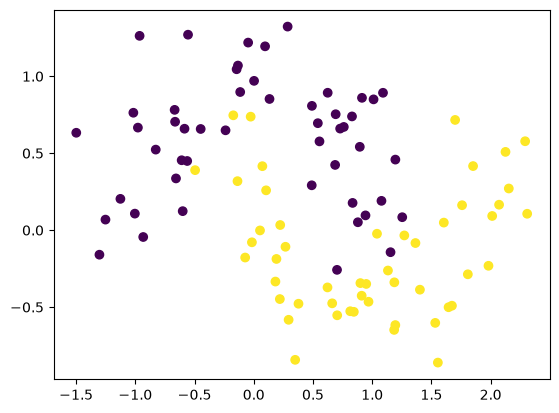

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [9]:
model1 = Sequential()

model1.add(Input(shape=(2,)))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

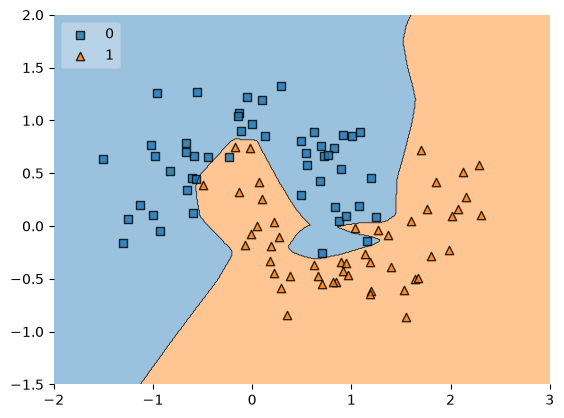

In [15]:
class KerasDecisionBoundaryWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return (probabilities > 0.5).astype(int).ravel()


model1_wrapper = KerasDecisionBoundaryWrapper(model1)
plot_decision_regions(X, y.astype('int'), clf=model1_wrapper, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

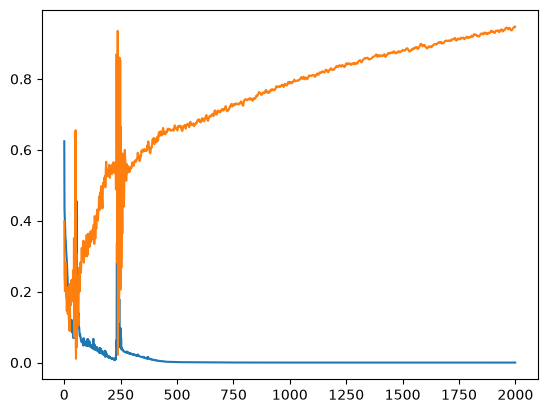

In [16]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [17]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

c:\Work\Practice\Deep-Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

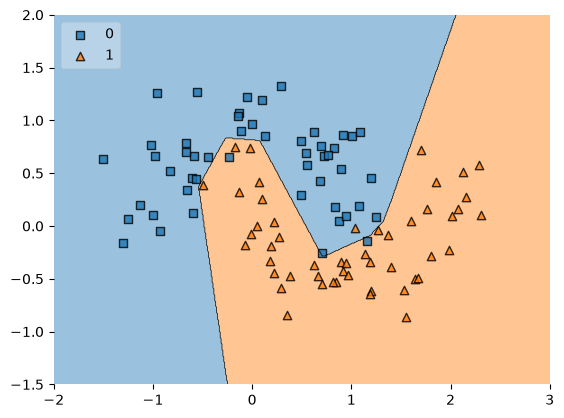

In [22]:
model2_wrapper = KerasDecisionBoundaryWrapper(model2)
plot_decision_regions(X, y.astype('int'), clf=model2_wrapper, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

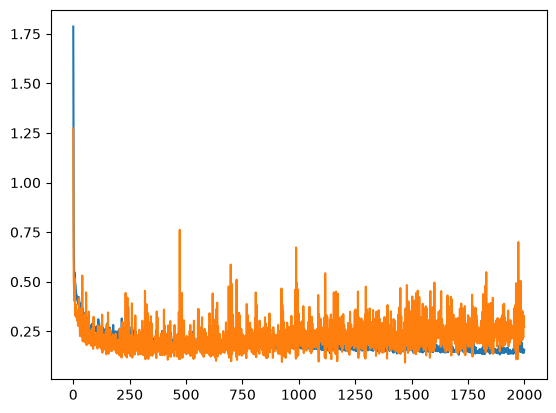

In [23]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [24]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

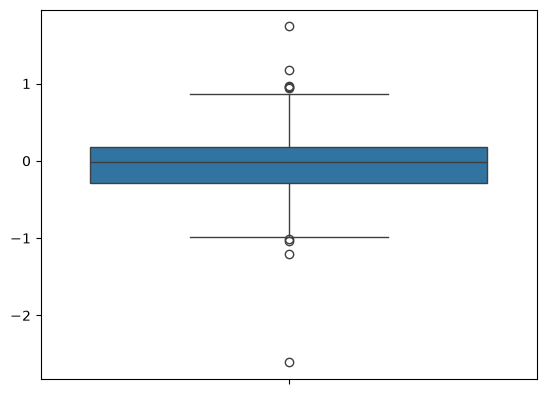

In [25]:
sns.boxplot(model1_weight_layer1)

In [26]:
model1.get_weights()[0].reshape(256)

array([-3.66799772e-01, -2.40330935e-01,  8.74367580e-02,  2.62064934e-01,
        2.16281474e-01, -2.36901671e-01,  2.88148254e-01,  3.05236399e-01,
       -4.32578832e-01, -3.39363515e-01, -9.06447917e-02, -4.69870895e-01,
       -3.25708956e-01, -4.26192164e-01,  4.01294202e-01, -4.44039226e-01,
        2.62413710e-01, -4.71365511e-01, -3.51464957e-01, -4.62202430e-01,
        4.49214019e-02, -4.27883446e-01,  1.67113960e-01, -2.88035180e-02,
       -1.64459720e-01, -1.87809616e-01,  8.92311276e-04,  3.23229671e-01,
        4.33324613e-02,  2.60634750e-01,  1.07504852e-01, -2.72527263e-02,
        1.85803846e-01, -2.08774909e-01,  3.10091376e-01,  3.36492002e-01,
        2.17808858e-01,  1.54536352e-01,  1.41328201e-01,  5.28866565e-03,
       -3.95957381e-01,  2.63480932e-01,  4.23085280e-02, -3.08674667e-02,
       -5.15242517e-01, -8.25990438e-02, -9.50094163e-02,  3.15944612e-01,
       -5.14215171e-01, -4.87391591e-01, -1.11184688e-02, -1.75218773e-03,
       -9.99696851e-02,  